--- Section 1: K-Means Clustering ---

Sample of generated blob data:
      Dim_1     Dim_2
0 -8.698618  6.571040
1 -2.664877  4.946613
2 -8.267989  4.453482
3 -8.062275  6.105848
4 -0.511279 -9.286752


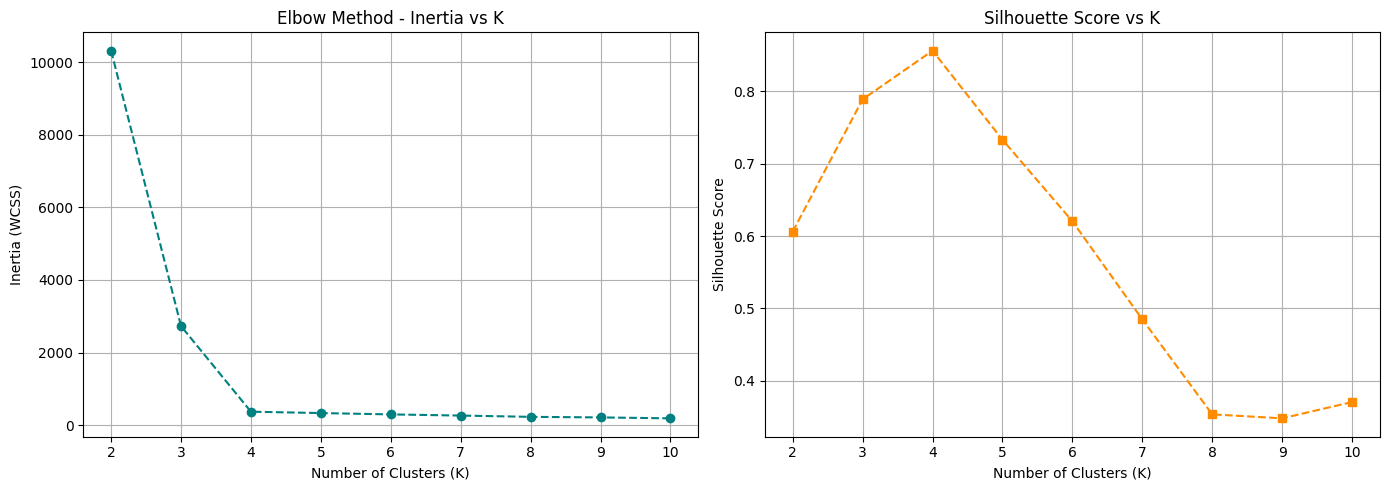


K selected by best silhouette score: 4


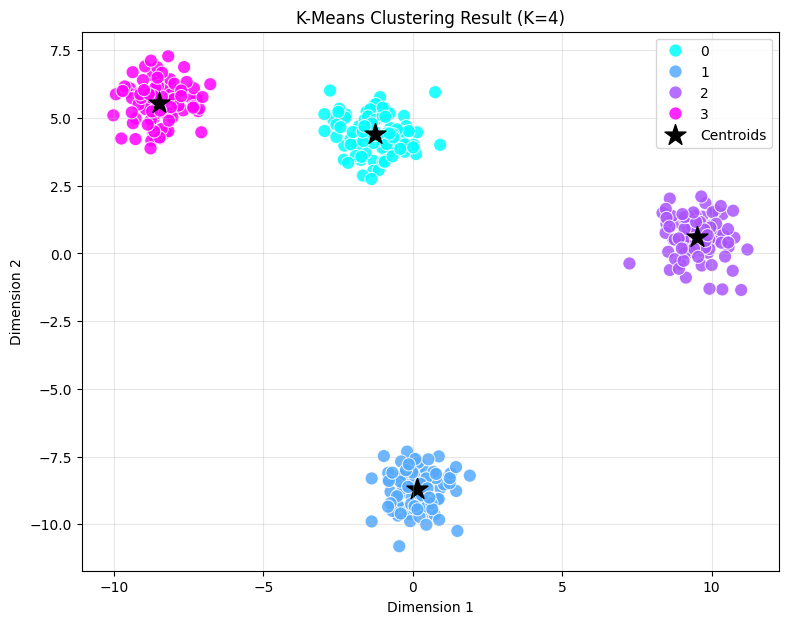


Final Silhouette Score (K=4): 0.856

--- Section 2: Dimensionality Reduction with PCA ---

Sample of high-dimensional data:
     Attr_1     Attr_2    Attr_3    Attr_4    Attr_5  Actual_Group
0  3.179301   5.599392 -4.616560 -2.827788 -7.697735             4
1  2.502660 -10.923077  0.507344  8.521785  5.108495             1
2  4.685450  -6.261545  8.523907  8.405145 -5.450637             2
3  2.971551  -8.933605 -4.099819 -4.114493 -7.034398             3
4 -6.646553  -8.374297 -0.245808  5.427380 -2.792904             0
Shape before reduction: (600, 6)

Reduced data sample:
        PC1       PC2  Actual_Group
0 -2.209794 -0.093232             4
1  1.619545  0.216421             1
2  0.621026  2.158751             2
3 -1.157467 -0.631401             3
4  1.225213 -0.725508             0

Explained variance per component: [0.52826893 0.26242757]
Combined variance explained by PC1 & PC2: 0.791


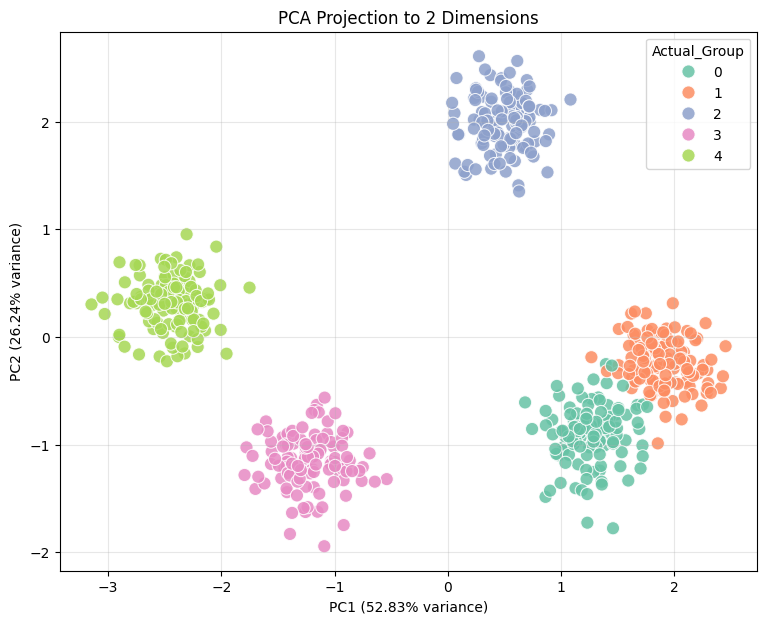

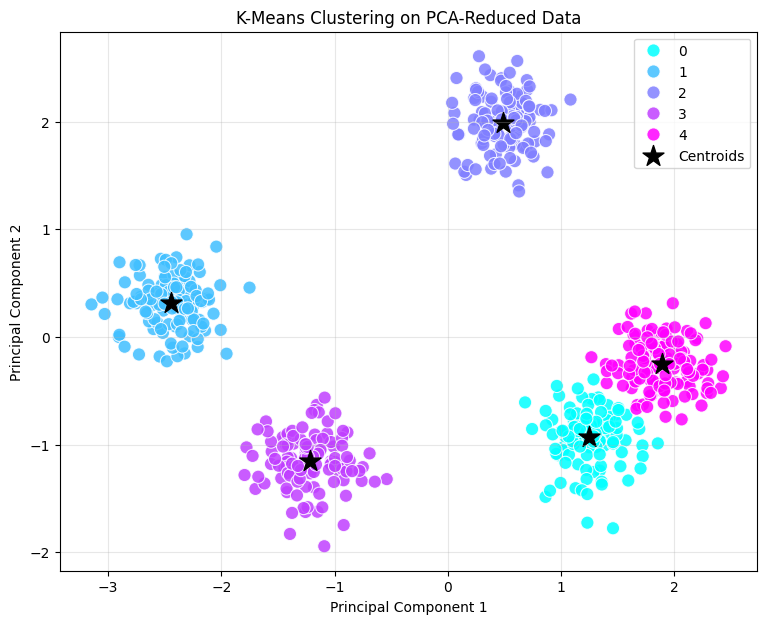


Silhouette Score for K-Means on PCA-Reduced Data (K=5): 0.707


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

print("--- Section 1: K-Means Clustering ---")

points, true_labels = make_blobs(n_samples=350, centers=4, cluster_std=0.75, random_state=7)
cluster_df = pd.DataFrame(points, columns=['Dim_1', 'Dim_2'])
print("\nSample of generated blob data:")
print(cluster_df.head())

inertia_scores = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    model = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=7)
    labels = model.fit_predict(points)
    inertia_scores.append(model.inertia_)
    silhouette_scores.append(silhouette_score(points, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(list(k_range), inertia_scores, marker='o', linestyle='--', color='teal')
ax1.set_title('Elbow Method - Inertia vs K')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.grid(True)

ax2.plot(list(k_range), silhouette_scores, marker='s', linestyle='--', color='darkorange')
ax2.set_title('Silhouette Score vs K')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True)
plt.tight_layout()
plt.show()

chosen_k = k_range[np.argmax(silhouette_scores)]
print(f"\nK selected by best silhouette score: {chosen_k}")

final_kmeans = KMeans(n_clusters=chosen_k, init='k-means++', max_iter=300, n_init=10, random_state=7)
final_labels = final_kmeans.fit_predict(points)
cluster_df['Cluster'] = final_labels

plt.figure(figsize=(9, 7))
sns.scatterplot(x='Dim_1', y='Dim_2', hue='Cluster', data=cluster_df, palette='cool', s=90, alpha=0.85)
plt.scatter(final_kmeans.cluster_centers_[:, 0], final_kmeans.cluster_centers_[:, 1],
            s=250, c='black', marker='*', label='Centroids')
plt.title(f'K-Means Clustering Result (K={chosen_k})')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

final_silhouette = silhouette_score(points, final_labels)
print(f"\nFinal Silhouette Score (K={chosen_k}): {final_silhouette:.3f}")

print("\n--- Section 2: Dimensionality Reduction with PCA ---")

high_dim_data, high_dim_labels = make_blobs(n_samples=600, n_features=5, centers=5, cluster_std=1.2, random_state=11)
raw_df = pd.DataFrame(high_dim_data, columns=[f'Attr_{i+1}' for i in range(high_dim_data.shape[1])])
raw_df['Actual_Group'] = high_dim_labels
print("\nSample of high-dimensional data:")
print(raw_df.head())
print(f"Shape before reduction: {raw_df.shape}")

standardizer = StandardScaler()
scaled_data = standardizer.fit_transform(high_dim_data)

pca_model = PCA(n_components=2)
reduced_data = pca_model.fit_transform(scaled_data)
pca_df = pd.DataFrame(reduced_data, columns=['PC1', 'PC2'])
pca_df['Actual_Group'] = high_dim_labels

variance_ratios = pca_model.explained_variance_ratio_
print("\nReduced data sample:")
print(pca_df.head())
print(f"\nExplained variance per component: {variance_ratios}")
print(f"Combined variance explained by PC1 & PC2: {variance_ratios.sum():.3f}")

plt.figure(figsize=(9, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Actual_Group', data=pca_df, palette='Set2', s=90, alpha=0.85)
plt.title('PCA Projection to 2 Dimensions')
plt.xlabel(f'PC1 ({variance_ratios[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({variance_ratios[1]*100:.2f}% variance)')
plt.grid(True, alpha=0.3)
plt.show()

pca_kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=7)
pca_cluster_labels = pca_kmeans.fit_predict(reduced_data)
pca_df['Cluster_on_PCA'] = pca_cluster_labels

plt.figure(figsize=(9, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster_on_PCA', data=pca_df, palette='cool', s=90, alpha=0.85)
plt.scatter(pca_kmeans.cluster_centers_[:, 0], pca_kmeans.cluster_centers_[:, 1],
            s=250, c='black', marker='*', label='Centroids')
plt.title('K-Means Clustering on PCA-Reduced Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

pca_silhouette = silhouette_score(reduced_data, pca_cluster_labels)
print(f"\nSilhouette Score for K-Means on PCA-Reduced Data (K=5): {pca_silhouette:.3f}")